<a href="https://colab.research.google.com/github/LuckyFork/deep-learning/blob/main/lecture2/pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What you will learn in this notebook

1. PyTorch tensors and operations on them
1. PyTorch autograd and backward method
1. PyTorch packages autograd, torchvision, datasets


### PyTorch Tensors
- A PyTorch ```tensor``` is an object that stores a multidimensional array
- A ```tensor``` according to [PyTorch documentation](https://pytorch.org/docs/stable/tensors.html) is a multidimensional matrix containing elements of a single data type.
- In addition to the data, a tensor has a large number of attributes and functions
- A PyTorch tensor has a similar interface to numpy arrays

### PyTorch Tensors

In [ ]:
import torch
# a 2-dim tensor created from a list of lists
b=torch.tensor([[1,2,3],[4,5,6]],dtype=torch.float32)
print("b={}".format(b))
print("b has dimensions {}".format(b.shape))
#torch.Size() is iterable so we can create a list or tuple
print("b has dimensions {}".format(tuple(b.shape)))


### PyTorch Tensors

In [ ]:

# A 0-dim tensor. Without dtype it will be implicitly an integer
a=torch.tensor(1,dtype=torch.float32)
print(a)
print(a.shape)
# use .item() to extract a scalar from a 0-d tensor
print("single value in a is {}".format(a.item()))

### Tensor slices
- Indexing and slices are similar to numpy


In [ ]:
print(b)
print(tuple(b.size()))
#print row index 0
print(b[0,:])
#print column index 1
print(b[:,1])

Given b below. What is the output of ```print(b[:,0:2])```? Use Vevox ID 159-794-831

In [ ]:
print(b)

In [ ]:
print(b[:,[0,2]])

1. $$\begin{bmatrix} 7 & 8 \\ 10 &11 \end{bmatrix}$$
1. $$\begin{bmatrix} 7 & 9 \\ 10 & 12 \end{bmatrix}$$
1. $$\begin{bmatrix} 8 & 9\\ 11& 12 \end{bmatrix}$$

### From/to numpy

In [ ]:
import numpy as np
a=np.array([[1,2,3],[4,5,6]],dtype=np.float32)### squeeze/unsqueeze/stack
b=torch.from_numpy(a)
print("b={}".format(b))
print("b has {} as data type".format(b.dtype))
print("convert b to numpy array")
print(b.numpy())

### Useful PyTorch operations

In [ ]:
# Create a tensor of shape (2,3) whose values are all zeros
a=torch.zeros([2,3])
print(a)
# Same as above but filled with ones
a=torch.ones([3,2])
print(a)
# Same as above but filled with random values from a uniform distribution over [0,1]
# https://pytorch.org/docs/stable/generated/torch.rand.html
a=torch.rand([2,3])
# See also randn for a normal distribution
#https://pytorch.org/docs/stable/generated/torch.randn.html

print(a)


### Useful operations for creating tensors

In [ ]:
# A tensor filled with ones that has the same dimensions as tensor a
b=torch.ones_like(a)
print(b)

# Transpose a tensor
a=torch.tensor([[1,2,3],[4,5,6]])
print("a=")
print(a)
print("transpose of a=")
print(a.transpose(0,1))

### Operations that change the shape of tensors
- In some situations one might need to add/remove dimensions from a tensor
- This can only be done if added/removed dimensionality size is one
- For example, a tensor of shape (1,3,3) or (2,1,2)
- Can be converted to (3,3) and (2,2)
- and vice-versa


### squeeze/unsqueeze/reshape

In [ ]:
a=torch.tensor([[1,2,3],[4.,5.,6.]])
print("a's shape",tuple(a.size()))
b=a.unsqueeze(0)
print("b's shape",tuple(b.size()))
c=a.unsqueeze(0).unsqueeze(2)
print("c's shape",tuple(c.size()))
d=c.squeeze()
print("d's shape", tuple(d.size()))
a.reshape(3,2)

### stack/flatten/view

In [ ]:
a=torch.tensor([1.,2,3])
b=torch.tensor([4,5.,6])
c=torch.stack((a,b))
print("c=",c)
d=torch.stack([a,b],dim=1)
print("d=",d)
print("d flattened=",d.flatten())
e=torch.stack([c,c])
print("e's shape is ",tuple(e.size()))
## view is used often in PyTorch models
e=e.view(e.size()[0],-1)
print("e's shape is ",tuple(e.size()))


### In-place tensor operations

- Given a tensor A
- Some operations on A create a copy of A
- Some operations (in-place) modify the tensor A itself. Usually have a "_" suffix

In [ ]:
a=torch.tensor([[1,2,3],[4,5,6]],dtype=torch.float32)
print(a.shape)
a.unsqueeze(0).shape

In [ ]:
print(a.shape)

In [ ]:
a.unsqueeze_(0)
print(a.shape)

In [ ]:
a=torch.tensor([[1,2,3],[4,5,6]])
b=torch.tensor([[7,8,9],[10,11,12]])
c=torch.stack([a,b],1)


What is the output below

In [ ]:
print(c[:,0,:])

Answer on Vevox with ID 159-794-831
1. $$\begin{bmatrix} 1 & 2 &3\\ 4 &5 &6 \end{bmatrix}$$
1. $$\begin{bmatrix} 1 & 2 &3\\ 7& 8 & 9 \end{bmatrix}$$
1. $$\begin{bmatrix} 1 & 4 & 7\\ 2& 5& 8 \end{bmatrix}$$

### More about in-place operations
- In addition to methods with an underscore suffix the following are also in-place
- +=,-=,*=,/=,
- using an index or slice, e.g. x[0]=2

In [ ]:
x=torch.tensor([1.,2])
y=torch.tensor([3.,4])
print(id(x))
x=x+y # a new tensor is allocated
print(id(x))
x+=y # this is an in-place operation
print(id(x))

In [ ]:
x=torch.tensor([1.,2])
y=torch.tensor([3.,4])
x=x+y # a new tensor is allocated
x+=y # this is an in-place operation
print(id(x))
x[0]=9
print(id(x))
print(x)

### Autograd package

- Deep learning involves optimization that require the computation of gradients
- An example was the linear regression discussed previously
- Using PyTorch's Autograd package one can automatically differentiate any function

In [ ]:
from torch.autograd import grad
x=torch.tensor(3.,requires_grad=True)
y=torch.tensor(2.,requires_grad=True)
z=x**2+4*y
r=grad(z,[x,y])
print(r)

### Using ```.backward()```

- An alternative may is to use the ```tensor.backward()``` method
- Unlike ```grad``` it does not return the gradients but **saves** them in ```.grad``` attribute of the dependent tensors

In [ ]:
x=torch.tensor(3.,requires_grad=True)
y=torch.tensor(2.,requires_grad=True)
z=x**2+4*y
z.backward()
print(x.grad,y.grad)

## PyTorch Dataset
- PyTorch has many built-in datasets
- They are all subclasses of ```torch.utils.data.Datasets```
- A subset of those datasets can be access in the ```torchvision.datasets```
- In the following example we will use the CIFAR10 dataset

- In most deep learning problem one needs a training dataset to train the model
- And a test dataset to gauge how well the trained model generalizes to unseen data

In [1]:
import torchvision as vision
# train=True is the default
cifar10_train=vision.datasets.CIFAR10(".",download=True,train=True)
cifar10_test=vision.datasets.CIFAR10(".",download=True,train=False)

100%|██████████| 170M/170M [00:02<00:00, 60.7MB/s]


### Exploring the dataset
- Almost always it helps to get an idea of the properties of the dataset
- For example, how many items

In [2]:
import numpy as np
train_samples=len(cifar10_train)
test_samples=len(cifar10_test)
print("The length of training data is {} and the test data is {}".format(train_samples,test_samples))


The length of training data is 50000 and the test data is 10000


- Classification datasets
- "raw" values are in ```dataset.data``` and ```dataset.targets```


In [3]:
np.unique(cifar10_train.targets)
print("data type={}, targets type={}".format(type(cifar10_train.data),type(cifar10_train.targets)))
print("possible targets values:")
np.unique(cifar10_train.targets)


data type=<class 'numpy.ndarray'>, targets type=<class 'list'>
possible targets values:


array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

### Datasets are subscriptable

- One can access invidual data elements using the subscript operator
- Note that an "element" is a tuple (pair

In [4]:
item=cifar10_train[0]
img=item[0]
label=item[1]
print(type(img),type(label))
# a more concise way
img,label=item
print(type(img),type(label))

<class 'PIL.Image.Image'> <class 'int'>
<class 'PIL.Image.Image'> <class 'int'>


### Iterating over a dataset
- Because datasets are **iterable** objects (see explanation [here](https://docs.python.org/3/glossary.html) ) the best way to explore the items is through an iterator.

In [5]:
# create an iterator to the dataset
itr=iter(cifar10_train)
#fetch the next item
item =next(itr)
print(type(item))

<class 'tuple'>


In [6]:
len(item)

2

In [7]:
img,label=item
print("First element has type={}, second has type={}".format(type(img),type(label)))

First element has type=<class 'PIL.Image.Image'>, second has type=<class 'int'>


### Can one iterate over the whole dataset?

In [8]:
itr=iter(cifar10_train)
count=0
while True:
    try:
        img,label=next(itr)
        count+=1
    except StopIteration:
        break
print(count)

50000


### for loop to the rescue
- That was the "low level" way of iteration over an **iterable**
- Python provides a "for" construct that hides those details

In [9]:
count=0
for item  in cifar10_train:
    img,label=item
    count+=1
print(count)

50000


### Visualizing the images

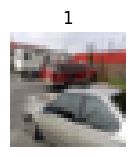

In [10]:
# Plot the first image (a frog) and set the corresponding label as title

import matplotlib.pyplot as plt
fig=plt.figure()
fig.set_size_inches(1.5,1.5)
p=fig.add_subplot()

p.set_title(str(label))
plt.axis('off')
plt.imshow(img)